# DataDriven_Soccer_Scouting

In [273]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import QuantileTransformer
import time
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "nbformat"])

import warnings
warnings.filterwarnings("ignore")

start_time = time.time()

## Introduction and EDA

In [274]:
df = pd.read_csv("merged_data.csv")
# Convert 'season' to a more readable format (e.g., '2020 - 2021')
df['season'] = df['season'].astype(str).str.zfill(4)
df['season'] = "20" + df['season'].str[:2] + " - 20" + df['season'].str[2:]

# Keep "Position" column instead of "pos"
df.drop(columns=['pos'], inplace=True)
df = df.rename(columns={'Position': 'pos'})

display(df.head())
print('\nRows: {}, Columns: {}'.format(df.shape[0], df.shape[1]))

,league,season,team,player,nation,age,born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Touches_Att Pen,Touches_Def 3rd,Touches_Def Pen,Touches_Live,Touches_Mid 3rd,Touches_Touches,Height,Weight,Preferred foot,pos
0,ENG-Premier League,2024 - 2025,Arsenal,Ben White,ENG,26,1997,17,13,1198,...,28,214,55,813,367,813,NaN,NaN,NaN,NaN
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,22,2001,25,20,1729,...,162,57,6,978,216,979,178.0,65.0,Left,RW
2,ENG-Premier League,2024 - 2025,Arsenal,David Raya,ESP,28,1995,38,38,3420,...,0,1388,880,1480,92,1480,183.0,75.0,Right,GK
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,25,1999,35,33,2825,...,81,325,82,1948,909,1948,185.0,80.0,Right,CDM
4,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Magalhães,BRA,26,1997,28,28,2363,...,40,672,189,1873,985,1873,NaN,NaN,NaN,NaN



Rows: 4807, Columns: 117


In [275]:
# Removing rows with null values and Goalkeepers (GK)
not_null_df = df.dropna()
not_null_df = not_null_df[not_null_df['pos'] != 'GK']
print('data without null and GKs\n- rows: {} \n- columns: {}'.format(not_null_df.shape[0], not_null_df.shape[1]))
df_backup = df.copy()
df = not_null_df.copy()

data without null and GKs
- rows: 3392 
- columns: 117


In [276]:
# Select all not numeric columns
not_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
display(df[not_numeric_cols].head())

,league,season,team,player,nation,Preferred foot,pos
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,Left,RW
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,Right,CDM
5,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Martinelli,BRA,Right,LW
6,ENG-Premier League,2024 - 2025,Arsenal,Jakub Kiwior,POL,Left,CB
7,ENG-Premier League,2024 - 2025,Arsenal,Jurriën Timber,NED,Right,RB


In [277]:
# Convert preferred_foot to binary (1 for 'Right', 0 for 'Left')
df.rename(columns={'Preferred foot': 'preferred_foot'}, inplace=True)
#df['preferred_foot_binary'] = df['preferred_foot'].map({'Right': 1, 'Left': 0})

# Identify info columns and create a separate DataFrame for them
info_columns = ['league', 'season', 'team', 'player', 'nation', 'pos', 'born', 'age', 'preferred_foot']
df_info = df[[col for col in df.columns if col.lower() in info_columns]].copy()
numeric_features = df.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_features if col.lower() not in info_columns]

X = df[features].copy()

print(f"Matrix 'X' shape: {X.shape[0]} players x {X.shape[1]} statistics")

# Split into test and train and scale values
X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

features_original = features.copy()

Matrix 'X' shape: 3392 players x 108 statistics


In [278]:
# Reset index of df_info for easier indexing later
df_info_reset = df_info.reset_index(drop=True)
df_info_reset


# Map macro positions to group similar roles together
pos_mapping = {
    'RB': 'Fullback',
    'LB': 'Fullback',
    'RW': 'Winger',
    'LW': 'Winger',
    'RM': 'Wide Midfielder',
    'LM': 'Wide Midfielder'
}
df_info_reset['macro_pos'] = df_info_reset['pos'].replace(pos_mapping)
unique_macro_positions = df_info_reset['macro_pos'].unique()

## Similarity Search

### PCA

Total features: 108
Explained variance by first 10 components: [0.31575586 0.55788425 0.63624612 0.68310534 0.716754   0.74762893
 0.77316808 0.79665371 0.81487514 0.83046335]
Variance explained by first 20 components: 0.9238
Components needed for 95% variance: 26
Components needed for 90% variance: 17


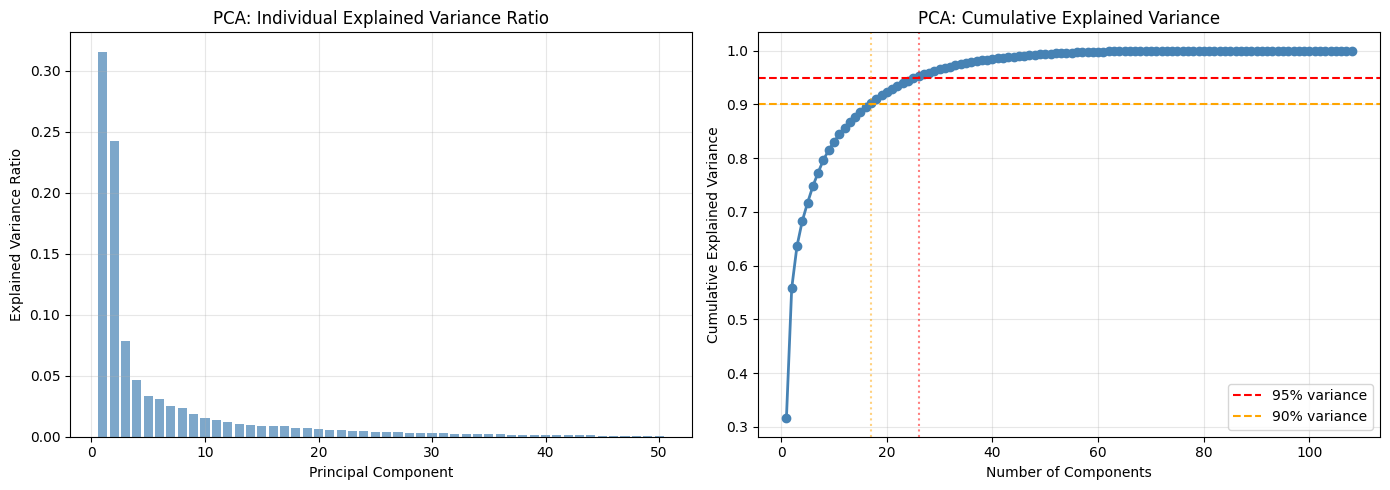

In [279]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Total features: {X_train_scaled.shape[1]}")
print(f"Explained variance by first 10 components: {cumulative_variance[:10]}")
print(f"Variance explained by first 20 components: {cumulative_variance[19] if len(cumulative_variance) > 19 else cumulative_variance[-1]:.4f}")

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 90% variance: {n_components_90}")

# Plot 1: Explained Variance Ratio for individual components
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_features_to_plot = min(50, len(explained_variance))
axes[0].bar(range(1, max_features_to_plot + 1), explained_variance[:max_features_to_plot], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA: Individual Explained Variance Ratio')
axes[0].grid(alpha=0.3)

# Plot 2: Cumulative Explained Variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', color='steelblue', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
axes[1].axvline(x=n_components_95, color='r', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_components_90, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('PCA: Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

First conclusion: Data is highly reducible: from 109 variables you can reduce to about 20–30 without losing much information.

In [280]:
pca_final = PCA(n_components=n_components_95) # o 18, o 0.95
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_val_pca = pca_final.transform(X_val_scaled)

# Reconstruction of the original data from the PCA components
X_train_reconstructed = pca_final.inverse_transform(X_train_pca)
X_val_reconstructed = pca_final.inverse_transform(X_val_pca)

# Compute the Mean Squared Error (MSE) between the original scaled data and the reconstructed data
mse_train = np.mean((X_train_scaled - X_train_reconstructed) ** 2, axis=1)
mse_val = np.mean((X_val_scaled - X_val_reconstructed) ** 2, axis=1)

# Verify Generalization
mean_mse_train = np.mean(mse_train)
mean_mse_val = np.mean(mse_val)

print(f"--- PCA Baseline Performance ({pca_final.n_components_} Components) ---")
print(f"Average Training Error:   {mean_mse_train:.4f}")
print(f"Average Validation Error: {mean_mse_val:.4f}")

if mean_mse_val > mean_mse_train * 1.5:
    print("⚠️ Warning: The Validation Error is much higher than the Training Error.")
    print("The principal components do not adequately describe the unseen data (Poor generalization).")
else:
    print("✅ Generalization OK: The training and validation errors are comparable and stable.")

--- PCA Baseline Performance (26 Components) ---
Average Training Error:   0.0474
Average Validation Error: 0.0531
✅ Generalization OK: The training and validation errors are comparable and stable.


In [281]:
# Create PCA latent dataframe
X_all_scaled = scaler.transform(X)
X_all_pca = pca_final.transform(X_all_scaled)
pca_columns = [f"PCA_{i+1}" for i in range(X_all_pca.shape[1])]
df_pca = pd.DataFrame(X_all_pca, columns=pca_columns)
df_latent_pca = pd.concat([df_info_reset.reset_index(drop=True), df_pca], axis=1)

### Deep Autoencoder - MURA

#### Relu

In [282]:
%%script echo skipping
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_train_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
input_layer = layers.Input(shape=(input_dim,))

# ENCODER 
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK 
bottleneck_layer = layers.Dense(16, activation='linear', name='dna_bottleneck')(encoded)

# DECODER
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output 
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, X_val_scaled),
    callbacks=[early_stop],
    verbose=1
)
print("Training completed!")

# Plot training & validation loss curves to check for overfitting
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.legend()
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 16D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
X_all_scaled = scaler.transform(X)
bottleneck_all = encoder.predict(X_all_scaled)

ae_columns = [f'AE_{i+1}' for i in range(16)]
df_ae = pd.DataFrame(bottleneck_all, columns=ae_columns)

df_latent_ae_relu = pd.concat([df_info_reset, df_ae], axis=1)

Couldn't find program: 'echo'


#### Tanh

In [283]:
%%script echo skipping
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_train_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
input_layer = layers.Input(shape=(input_dim,))

# ENCODER
encoded = layers.Dense(64, activation='tanh')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK
bottleneck_layer = layers.Dense(16, activation='linear', name='dna_bottleneck')(encoded)

# DECODER
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)

# Final output
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, X_val_scaled),
    callbacks=[early_stop],
    verbose=1
)
print("Training completed!")

# Plot training & validation loss curves to check for overfitting
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.legend()
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 16D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)

X_all_scaled = scaler.transform(X)
bottleneck_all = encoder.predict(X_all_scaled)

ae_columns = [f'AE_{i+1}' for i in range(16)]
df_ae = pd.DataFrame(bottleneck_all, columns=ae_columns)

df_latent_ae_tanh = pd.concat([df_info_reset, df_ae], axis=1)

Couldn't find program: 'echo'


#### ReLU with dropout

In [284]:
%%script echo skipping
print("--- Building Deep Autoencoder with Dropout ---")

input_dim = X_train_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
input_layer = layers.Input(shape=(input_dim,))

# ENCODER
encoded = layers.Dense(128, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK
bottleneck_layer = layers.Dense(16, activation='linear', name='dna_bottleneck')(encoded)

# DECODER
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='relu')(decoded)

# Final output
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=500, 
    batch_size=32,
    validation_data=(X_val_scaled, X_val_scaled),
    callbacks=[early_stop],
    verbose=1
)
print("Training completed!")

# Plot training & validation loss curves to check for overfitting
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Huber)' )
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 16D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)

X_all_scaled = scaler.transform(X) 
bottleneck_all = encoder.predict(X_all_scaled)

ae_columns = [f'AE_{i+1}' for i in range(16)]
df_ae_relu_dropout = pd.DataFrame(bottleneck_all, columns=ae_columns)

df_latent_ae_relu_dropout = pd.concat([df_info_reset, df_ae_relu_dropout], axis=1)

Couldn't find program: 'echo'


#### Tanh with dropout

In [285]:
%%script echo skipping
print("--- Building Deep Autoencoder with Dropout ---")

input_dim = X_train_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
input_layer = layers.Input(shape=(input_dim,))

# ENCODER
encoded = layers.Dense(128, activation='tanh')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='tanh')(encoded)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK
bottleneck_layer = layers.Dense(16, activation='linear', name='dna_bottleneck')(encoded)

# DECODER
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='tanh')(decoded)

# Final output
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=500, 
    batch_size=32,
    validation_data=(X_val_scaled, X_val_scaled),
    callbacks=[early_stop],
    verbose=1
)
print("Training completed!")

# Plot training & validation loss curves to check for overfitting
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Huber)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 16D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)

X_all_scaled = scaler.transform(X) 
bottleneck_all = encoder.predict(X_all_scaled)

ae_columns = [f'AE_{i+1}' for i in range(16)]
df_ae_tanh_dropout = pd.DataFrame(bottleneck_all, columns=ae_columns)

df_latent_ae_tanh_dropout = pd.concat([df_info_reset, df_ae_tanh_dropout], axis=1)

Couldn't find program: 'echo'


### Testing Models

#### Similarity Functions

In [286]:
%%script echo skipping
def find_similar_ae(player_name, player_season, latent_df, top_n=5, max_age=None, season_filter=None, same_macro_position=False, same_league=False, same_preferred_foot=False):
    # Find player index by name and season
    mask_target = (
        (latent_df['player'].str.lower() == player_name.lower())
        & (latent_df['season'] == player_season)
    )
    player_idx = latent_df[mask_target].index

    if len(player_idx) == 0:
        return "Player not found in the database."

    idx = player_idx[0]
    real_player = latent_df.loc[idx, 'player']
    real_team = latent_df.loc[idx, 'team']
    season = latent_df.loc[idx, 'season']
    role = latent_df.loc[idx, 'macro_pos']

    # Dynamically detect latent columns (AE_* or PCA_*)
    latent_cols = [col for col in latent_df.columns if col.startswith('AE_') or col.startswith('PCA_')]
    
    model_type = "PCA" if latent_cols[0].startswith('PCA_') else "AUTOENCODER"
    print(f"\n[{model_type}] Searching similar players for: {real_player} ({real_team} - {season})")

    # Compute cosine similarity
    player_vector = latent_df.loc[idx, latent_cols].values.reshape(1, -1)
    all_vectors = latent_df[latent_cols].values
    similarity = cosine_similarity(player_vector, all_vectors)[0]

    # Assign scores
    latent_df_temp = latent_df.copy()
    latent_df_temp['Similarity_Score'] = similarity
    latent_df_temp = latent_df_temp.drop(index=idx)

    # Optional filters
    if max_age is not None:
        latent_df_temp = latent_df_temp[latent_df_temp['age'] <= max_age]
    if season_filter is not None:
        latent_df_temp = latent_df_temp[latent_df_temp['season'] == season_filter]
    if same_macro_position:
        latent_df_temp = latent_df_temp[latent_df_temp['macro_pos'] == role]
    if same_league:
        latent_df_temp = latent_df_temp[latent_df_temp['league'] == latent_df.loc[idx, 'league']]
    if same_preferred_foot:
        latent_df_temp = latent_df_temp[latent_df_temp['preferred_foot'] == latent_df.loc[idx, 'preferred_foot']]

    # Sort from most similar to least similar and exclude the target player
    latent_df_temp = latent_df_temp[latent_df_temp['player'] != player_name]
    similar_players = latent_df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()
    similar_players['Match %'] = (similar_players['Similarity_Score'] * 100).round(1).astype(str) + '%'

    # Format output
    output_columns = ['player', 'age', 'team', 'macro_pos', 'league', 'season', 'Match %']
    return similar_players[output_columns]

Couldn't find program: 'echo'


In [287]:
def find_similar_ensemble_zscore(
    player_name,
    player_season,
    latent_df_tanh, 
    latent_df_pca,  
    weight_tanh=0.70, 
    weight_pca=0.30,  
    top_n=5,
    max_age=None,
    season_filter=None,
    same_macro_position=False,
    same_league=False
    ):
    
    # 1. Find player index by name and season in the Tanh latent dataframe (as reference)
    mask_target = (
        (latent_df_tanh['player'].str.lower() == player_name.lower())
        & (latent_df_tanh['season'] == player_season)
    )
    player_idx = latent_df_tanh[mask_target].index

    if len(player_idx) == 0:
        return "Player not found in the database."

    idx = player_idx[0]
    
    # Player info 
    real_player = latent_df_tanh.loc[idx, 'player']
    real_team = latent_df_tanh.loc[idx, 'team']
    season = latent_df_tanh.loc[idx, 'season']
    role = latent_df_tanh.loc[idx, 'macro_pos']
    league = latent_df_tanh.loc[idx, 'league']

    print(f"\n[ENSEMBLE Z-SCORE] Searching similar players for: {real_player} ({real_team} - {season})")
    print(f"Weights used: {weight_tanh*100}% Tanh, {weight_pca*100}% PCA")

    # Identify latent columns for both dataframes
    cols_tanh = [col for col in latent_df_tanh.columns if col.startswith('AE_') or col.startswith('PCA_')]
    cols_pca = [col for col in latent_df_pca.columns if col.startswith('AE_') or col.startswith('PCA_')]
    
    # Extract target player vectors (shape: 1xN)
    vec_tanh = latent_df_tanh.loc[idx, cols_tanh].values.reshape(1, -1)
    vec_pca = latent_df_pca.loc[idx, cols_pca].values.reshape(1, -1)

    # Compute cosine similarity for both models
    sim_tanh = cosine_similarity(vec_tanh, latent_df_tanh[cols_tanh].values)[0]
    sim_pca = cosine_similarity(vec_pca, latent_df_pca[cols_pca].values)[0]

    # Standardization (Z-Score)
    z_sim_tanh = (sim_tanh - np.mean(sim_tanh)) / np.std(sim_tanh)
    z_sim_pca = (sim_pca - np.mean(sim_pca)) / np.std(sim_pca)

    # Ensamble Z-Score
    z_ensemble = (z_sim_tanh * weight_tanh) + (z_sim_pca * weight_pca)

    df_temp = latent_df_tanh.copy()
    df_temp['Sim_Tanh'] = sim_tanh
    df_temp['Sim_PCA'] = sim_pca
    df_temp['Z_Score_Ensemble'] = z_ensemble

    # Compute Match Score as a percentage (0-100%) based on the ensemble Z-Score
    min_z = z_ensemble.min()
    max_z = z_ensemble.max()
    df_temp['Match_Score_Scaled'] = (z_ensemble - min_z) / (max_z - min_z)

    # Remove the target player from the results
    df_temp = df_temp.drop(index=idx)
    df_temp = df_temp[df_temp['player'] != real_player]

    # Apply optional filters
    if max_age is not None:
        df_temp = df_temp[df_temp['age'] <= max_age]
    if season_filter is not None:
        df_temp = df_temp[df_temp['season'] == season_filter]
    if same_macro_position:
        df_temp = df_temp[df_temp['macro_pos'] == role]
    if same_league:
        df_temp = df_temp[df_temp['league'] == league]

    # Format output
    similar_players = df_temp.sort_values(by='Z_Score_Ensemble', ascending=False).head(top_n).copy()
    similar_players['Match %'] = (similar_players['Match_Score_Scaled'] * 100).round(1).astype(str) + '%'
    similar_players['(Tanh raw)'] = (similar_players['Sim_Tanh'] * 100).round(1).astype(str) + '%'
    similar_players['(PCA raw)'] = (similar_players['Sim_PCA'] * 100).round(1).astype(str) + '%'
    
    return similar_players[['player', 'age', 'team', 'macro_pos', 'league', 'season', 'Match %', '(Tanh raw)', '(PCA raw)']]

#### Testing

##### Single Testing

In [288]:
%%script echo skipping
# Testing the models with a target player and season
target_player = "Riccardo Orsolini"
target_season = "2024 - 2025"
max_age = None

models_to_test = {
    'PCA': df_latent_pca,
    'Relu': df_latent_ae_relu,
    'Tanh': df_latent_ae_tanh,
    'ReLU + Dropout': df_latent_ae_relu_dropout,
    'Tanh + Dropout': df_latent_ae_tanh_dropout,
}

for model_name, model_df in models_to_test.items():
    print(f"\n===== Model: {model_name} =====")
    ae_results = find_similar_ae(
        player_name=target_player,
        player_season=target_season,
        latent_df=model_df,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_macro_position=False
    )
    display(ae_results)

print("\n===== Model: Ensemble =====")
ensemble_results = find_similar_ensemble_zscore(
    player_name=target_player,
    player_season=target_season,
    latent_df_tanh=df_latent_ae_tanh,
    latent_df_pca=df_latent_pca,
    top_n=5,
    max_age=max_age,
    season_filter=None,
    same_macro_position=True,
    same_league=False
)
display(ensemble_results)

Couldn't find program: 'echo'


##### Bulk Testing

In [289]:
%%script echo skipping
# Single table with all results (target player x model)
target = ["Kevin De Bruyne", "Alessandro Bastoni", "Manuel Locatelli", "Andrea Pinamonti", 'Erling Haaland', "Xavi Simons", "Riccardo Orsolini"]
same_position = [False, False, False, False, False, False, False]
max_age = 23

target_same_position = dict(zip(target, same_position))
all_results = []

for player in target:
    for model_name, model_df in models_to_test.items():
        res = find_similar_ae(
            player_name=player,
            player_season=target_season,
            latent_df=model_df,
            top_n=5,
            max_age=max_age,
            season_filter=None,
            same_macro_position=target_same_position[player],
            same_league=False,
            same_preferred_foot=False
        )

        if isinstance(res, pd.DataFrame):
            res = res.copy()
            res["target_player"] = player
            res["target_season"] = target_season
            res["model_used"] = model_name
            res["rank"] = range(1, len(res) + 1)
            all_results.append(res)

    # Add the ensemble result as well
    res_ensemble = find_similar_ensemble_zscore(
        player_name=player,
        player_season=target_season,
        latent_df_tanh=df_latent_ae_tanh,
        latent_df_pca=df_latent_pca,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_macro_position=target_same_position[player],
        same_league=False
    )

    if isinstance(res_ensemble, pd.DataFrame):
        res_ensemble = res_ensemble.copy()
        res_ensemble["target_player"] = player
        res_ensemble["target_season"] = target_season
        res_ensemble["model_used"] = "Ensemble"
        res_ensemble["rank"] = range(1, len(res_ensemble) + 1)
        all_results.append(res_ensemble)

# Final grouped DataFrame
grouped_results_table = pd.concat(all_results, ignore_index=True)

# Column order for readability
grouped_results_table = (
    grouped_results_table[
        ["target_player", "target_season", "model_used", "rank", "player", "age", "team", "macro_pos", "league", "season", "Match %"]
    ]
    .sort_values(["target_player", "model_used", "rank"])
    .reset_index(drop=True)
)

display(grouped_results_table)

Couldn't find program: 'echo'


In [290]:
%%script echo skipping
grouped_results_table.to_csv("resources\grouped_results_table.csv", index=False)

Couldn't find program: 'echo'


### Choice explanation

### 🎯 Goal: The "Hidden Gem" Engine
Our ultimate business objective is to find **affordable, tactically identical replacements** for elite players. To achieve this, the final architecture relies on a **Z-Score Weighted Ensemble** combining two distinct models:
* **70%** Tanh Deep Autoencoder (Tactical precision)
* **30%** Principal Component Analysis (Volume & Quality)

---

### 🛠️ Why This Architecture Wins

**1. Discarding Dropout & ReLU**
* 🚫 **The Problem:** *Dropout* adds artificial noise (causing the model to confuse distinct roles), while *ReLU* flattens negative statistics (losing crucial tactical nuances).
* ✅ **The Fix:** A pure **Tanh** activation function without dropout preserves a player's exact "tactical DNA" and strictly respects their pitch position.

**2. Overcoming the Limits of Pure PCA**
* ⚠️ **The Problem:** PCA brilliantly captures global game volume, but it is heavily biased toward expensive, established superstars. Used alone, it fails the "affordable replacement" objective.

**3. The Power of Z-Score Standardization**
* 📊 **The Fix:** Simply averaging raw similarity percentages is mathematically flawed due to different scaling. Converting outputs to **Z-Scores** standardizes the metrics, allowing for a robust, "apples-to-apples" aggregation.

**4. The 70/30 Strategic Weighting**
* ⚖️ **70% Tanh (The Scout):** Firmly prioritizes tactical discipline, positional fidelity, and uncovers undervalued "hidden gems."
* ⚖️ **30% PCA (The Filter):** Acts as a quality assurance filter, ensuring the recommended player possesses a comparable volume of play to the target.

---

### ⚙️ Technical Specifications

To build this ensemble, we compress the original **109-dimensional feature space** using two distinct dimensionality reduction algorithms.

#### 🧠 1. Nonlinear Tactical Extraction (Deep Autoencoder)
* **Architecture:** Symmetric feedforward neural network (`109 → 64 → 32 → 16 → 32 → 64 → 109`).
* **Activation (`Tanh`):** Used across all hidden layers to capture complex, non-linear tactical relationships while maintaining strict positional boundaries.
* **Loss Function (`Huber`):** Explicitly chosen over standard MSE. Soccer statistics naturally contain extreme outliers (e.g., skewed metrics for low-playtime players); Huber loss prevents these anomalies from skewing the network's weights.
* **Latent Space:** A **16-node linear bottleneck** (`dna_bottleneck`) provides a highly compressed, dense tactical signature.

#### 📉 2. Global Volume Extraction (PCA)
* **Variance Target:** Configured to retain exactly **95%** of the cumulative explained variance.
* **Dimensionality:** Achieves the 95% threshold using **27 principal components**, effectively reducing noise while preserving global statistical weight.
* **Generalization:** Empirical validation confirms model stability, with the Mean Squared Error (MSE) remaining comparable and low between the training (**0.0469**) and validation (**0.0526**) datasets.

#### Save csv models

In [291]:
%%script echo skipping
print("--- Final extraction and saving of vector databases ---")

print("Saving Tanh model...")
df_latent_ae_tanh.to_csv("saved_models/database_dna_tanh.csv", index=False)

print("Saving PCA model...")
df_latent_pca.to_csv("saved_models/database_dna_pca.csv", index=False)

print("CSV files saved successfully.")

Couldn't find program: 'echo'


## Anomaly Detection

### KMeans clustering: Cluster players and look for minorities into clusters - MURA

#### KMeans algorithm

In [292]:
X_scaled = scaler.fit_transform(X)
                    
noisy_columns = [
    # Minutaggio
    'Playing Time_MP',      
    'Playing Time_Starts',  
    'Playing Time_Min',      
    'Playing Time_90s', 
    '90s',                  
    
    # Rigori (Inquinano il profilo open-play)
    'Performance_PK',       
    'Performance_PKatt',    
    'Standard_PK',            
    'Standard_PKatt',
    
    # Disciplina ed Errori (Eventi rari che rompono la loss function)
    'Performance_CrdY',
    'Performance_CrdR',
    'Err',
    
    # Overperformance & Form (Non indicano il ruolo tattico)
    'Expected_G-xG',
    'Expected_np:G-xG',
    'Expected_A-xAG',
    
    # Ridondanze Macro (Manteniamo solo le versioni npxG e G-PK)
    'Performance_Gls',
    'Performance_G+A',
    'Expected_xG',
    'Per 90 Minutes_Gls',
    'Per 90 Minutes_G+A',
    'Per 90 Minutes_G-PK',
    'Per 90 Minutes_G+A-PK',
    'Per 90 Minutes_xG',
    'Per 90 Minutes_xG+xAG'
    
    # Removed to reduce noise and redundancy (little sample effect)
    'Take-Ons_Succ%', 
    'Take-Ons_Tkld%', 
    'Standard_SoT%', 
    'Long_Cmp%', 
    'Medium_Cmp%', 
    'Short_Cmp%', 
    'Total_Cmp%',
    'Challenges_Tkl%'
]


# Build a DataFrame from the scaled array then drop noisy columns
df_scaled = pd.DataFrame(X_scaled, columns=features, index=X.index)
df_clean = df_scaled.drop(columns=noisy_columns, errors='ignore')

features = df_clean.columns.tolist()

In [293]:
# L2 normalization of the feature matrix to avoid minutes played dominating the similarity calculations
X_normalized = normalize(df_clean, norm='l2')

k=20

# K-means clustering on the normalized data
kmeans = KMeans(
    n_clusters=20,      
    n_init=50,              
    random_state=42     
)
cluster_labels = kmeans.fit_predict(X_normalized)

# Add cluster column to the info DataFrame for analysis
df_clusters = df_info_reset.copy()
df_clusters['cluster'] = cluster_labels

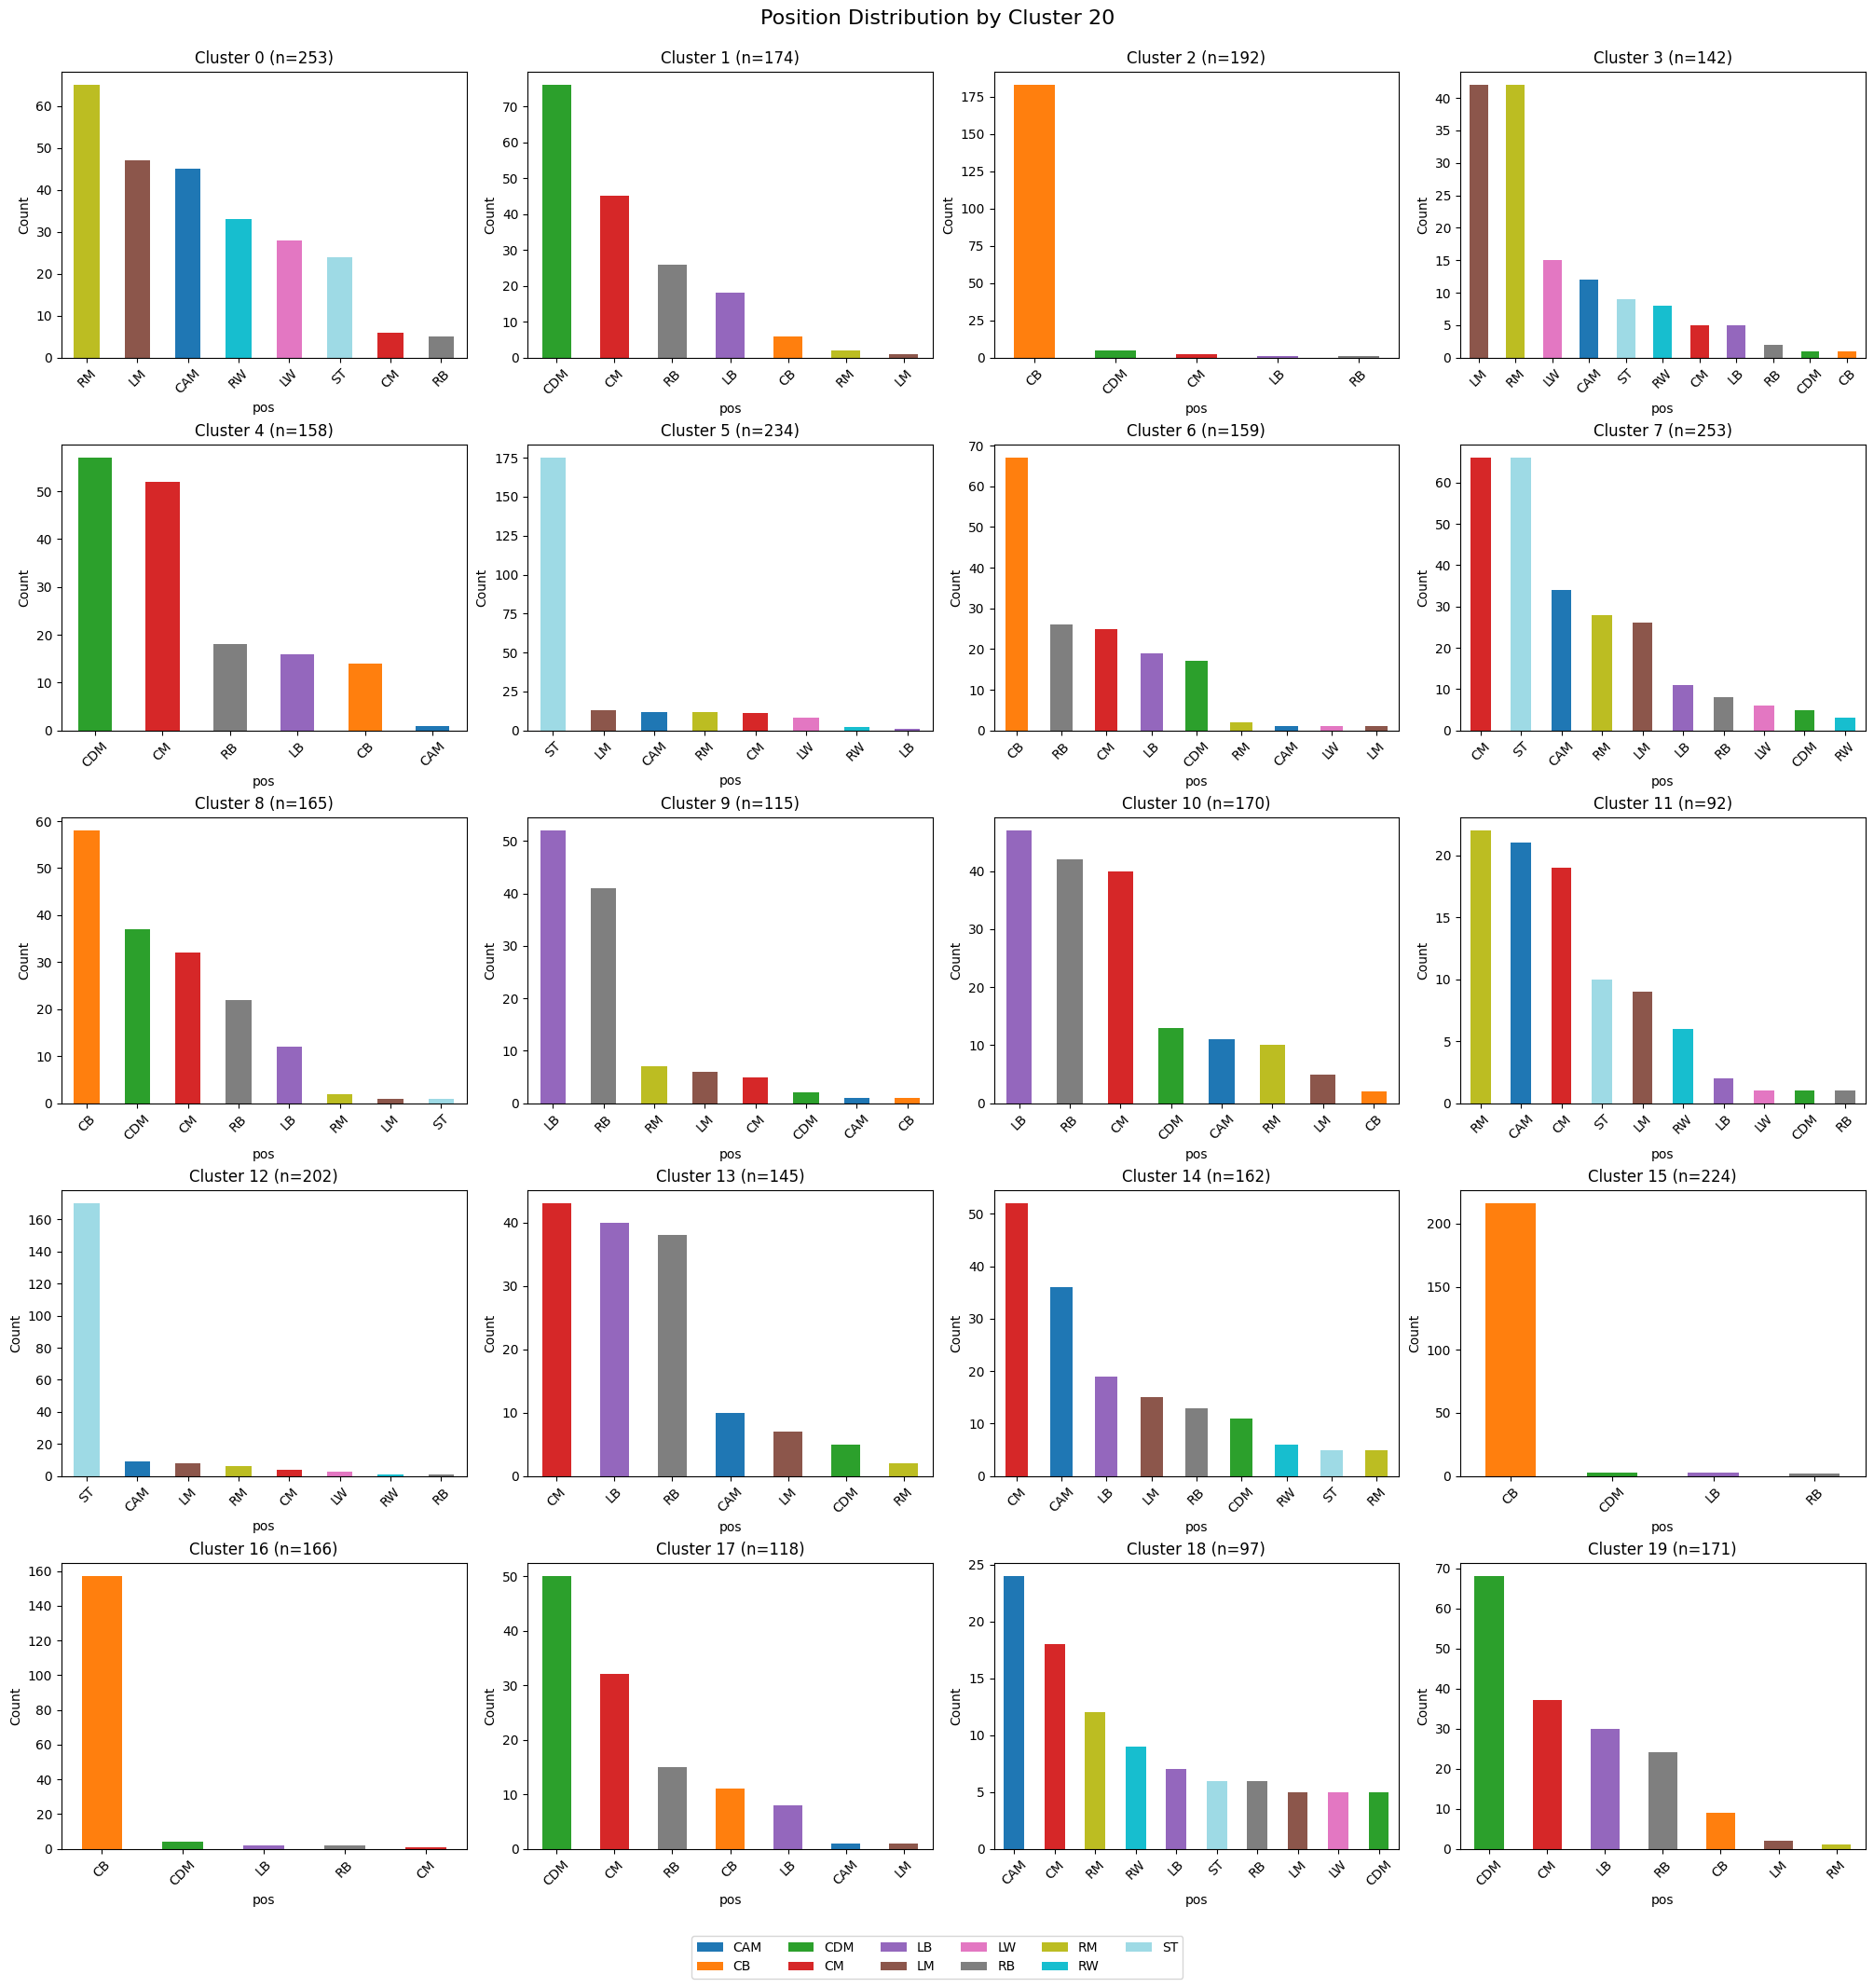

In [294]:
# ===========================================================================
#  Visualize the distribution of positions within each cluster for KMeans A
# ===========================================================================
cluster_col = "cluster"
pos_col = "pos"

# Create a color mapping for positions
unique_positions = sorted(df_clusters[pos_col].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_positions)))
color_map = {pos: colors[i] for i, pos in enumerate(unique_positions)}

n_clusters = df_clusters[cluster_col].nunique()
n_cols = 4
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), constrained_layout=True)
axes = np.array(axes).ravel()

for cluster_id in sorted(df_clusters[cluster_col].unique()):
    ax = axes[cluster_id]
    cluster_data = df_clusters[df_clusters[cluster_col] == cluster_id]
    pos_counts = cluster_data[pos_col].value_counts()

    # Map colors to each position
    bar_colors = [color_map[pos] for pos in pos_counts.index]
    pos_counts.plot(kind="bar", ax=ax, color=bar_colors)
    ax.set_title(f"Cluster {cluster_id} (n={len(cluster_data)})")
    ax.set_xlabel("pos")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

# Create legend with position colors
legend_elements = [plt.Rectangle((0, 0), 1, 1, facecolor=color_map[pos], label=pos) for pos in unique_positions]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=len(unique_positions)//2 + 1, fontsize=10)

plt.suptitle(f"Position Distribution by Cluster {k}", y=1.02, fontsize=16)
plt.show()

In [295]:
# Identify the dominant position in each cluster and save it the df in resources for later use in the web app
df_clusters['Dominant_Role_in_Cluster'] = df_clusters.groupby('cluster')['pos'].transform(
    lambda x: x.value_counts().idxmax()
)

df_clusters.to_csv("resources/df_clusters.csv", index=False)

#### Cluster Analysis

##### Inter-Cluster analysis

In [296]:
glossary = pd.read_excel("resources\glossary.xlsx")

# Create glossary lookup dictionary
glossary_dict = dict(zip(glossary['KPI'], glossary['Explanation']))

cluster_profile = []

for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    
    # 1. Dominant Role in Cluster
    pos_counts = cluster_data['pos'].value_counts()
    most_freq_pos_str = f"{pos_counts.index[0]} ({pos_counts.iloc[0]}, {(pos_counts.iloc[0]/len(cluster_data)*100):.1f}%)"
    
    # 2. Other Roles in Cluster
    other_pos_list = [f"{pos} ({count}, {(count/len(cluster_data)*100):.1f}%)" for pos, count in pos_counts.iloc[1:].items()]
    other_pos = ', '.join(other_pos_list)
    
    # 3. Feature Extraction from K-Means
    cluster_center = kmeans.cluster_centers_[cluster_id]
    sorted_idx = np.argsort(cluster_center)[::-1]
    pos_indices = [i for i in sorted_idx if cluster_center[i] > 0]
    neg_indices = [i for i in sorted_idx[::-1] if cluster_center[i] < 0] 
    
    def get_feature_str(indices, k=3, is_positive=True):
        res = []
        for i in indices[:k]:
            val = cluster_center[i]
            sign = "+" if is_positive else ""
            res.append(f"{features[i]} ({sign}{val:.2f})")
        while len(res) < k:
            res.append("-")
        return res
    pos_features = get_feature_str(pos_indices, k=3, is_positive=True)
    neg_features = get_feature_str(neg_indices, k=3, is_positive=False)
    
    # Add all info to the cluster profile list
    cluster_profile.append({
        'cluster': cluster_id,
        'player_count': len(cluster_data),
        'dominant_role': most_freq_pos_str,
        'other_positions': other_pos if other_pos else '-',
        'top_pos_1': pos_features[0],
        'top_pos_2': pos_features[1],
        'top_pos_3': pos_features[2],
        'top_neg_1': neg_features[0],
        'top_neg_2': neg_features[1],
        'top_neg_3': neg_features[2]
    })

# Compute final cluster profile DataFrame
df_cluster_profile = pd.DataFrame(cluster_profile)

In [ ]:
# Add scouting reports based on the cluster characteristics 
scouting_reports = {
    0: "Elite Agility Wingers - Short and light wingers specialized in dribbling and carrying the ball into the opponent's penalty area. They offer zero defensive presence against shots or clearances.",
    1: "Long-Range Shield - Defensive midfielders who guard the middle third and distribute from distance. They are strong in tackling but provide virtually zero offensive production or finishing efficiency.",
    2: "Low-Block Wall - Old-school center-backs. They dominate their own penalty area with clearances and blocked shots. They almost never participate in advanced build-up or receive progressive passes.",
    3: "Vertical Dribblers - Wide players heavily focused on progressing the ball via carries and take-ons. They skip the midfield passing network and provide very little defensive contribution.",
    4: "Central Metronomes - Playmakers who manage possession in the middle third and distribute the ball into the final third. They are the heart of the build-up but never personally threaten the goal.",
    5: "Ghost-Poachers - Pure forwards with elite expected goals and shooting volume per 90 minutes. They are completely isolated from the build-up, touching the ball and passing extremely rarely.",
    6: "Clinical Aerial Threats - Center-backs who take very few shots but are highly lethal when they do, likely converting set pieces. They rarely carry the ball or attempt open-play shots.",
    7: "Inefficient Volume Shooters - Midfielders or attackers who attempt many shots per 90 but are largely disconnected from live-ball touches, passing networks, and overall possession.",
    8: "Physical Giants - Tall and heavy center-backs who rely on their physical frame. They stay extremely deep, rarely receive the ball in build-up, and avoid carrying the ball forward.",   
    9: "Crossing Specialists - Fullbacks completely dedicated to wide delivery, launching crosses and passes into the penalty area from distance. They have virtually zero direct goal-scoring threat.",
    10: "Lightweight Wide Creators - Small-framed fullbacks and wide players who generate expected assisted goals via crosses from distance. They lack physical presence and receive few passes overall.",
    11: "High-Risk/Low-Reward Dribblers - Wide players who attempt to carry and dribble but are frequently dispossessed or tackled. They fail to progress the ball significant distances and struggle with medium passing.",
    12: "Specialized Finishers - Elite goal-scoring strikers who accumulate high non-penalty goals and expected goals. Their sole focus is scoring, offering absolute zero contribution in defensive tackling or interceptions.",
    13: "Aggressive Midfield Destroyers - Smaller-framed central midfielders who aggressively contest the ball, block passes, and tackle. They sacrifice all shooting and goal-scoring threat for defensive disruption.",
    14: "Pure Playmakers - Light and technical attacking midfielders focused entirely on chance creation and key passes. They offer zero physical dominance or defensive clearances.",
    15: "First-Phase Specialists - Center-backs who exclusively handle the early build-up in their own third via medium-range passing. They never venture forward and do not receive progressive passes.",
    16: "Deep-Lying Towers - Tall center-backs glued to their own penalty area, tasked with making clearances. They play extremely safe, never touching the ball in the final third and rarely turning the ball over on carries.",
    17: "Midfield Anchors - Deep-lying midfielders who safely recycle possession in the middle third and pass into the final third. They never enter the attacking penalty area and offer zero direct goal contributions.",
    18: "Final-Third Specialists - Attacking midfielders and wingers who live in the opponent's half, providing elite assists and expected assisted goals. They completely ignore defensive duties in their own third.",
    19: "High-Volume Defensive Grinders - Defensive midfielders entirely defined by their ability to win tackles and intercept the ball. They are true defensive specialists with non-existent offensive output."
}

df_cluster_profile['scouting_report'] = df_cluster_profile['cluster'].map(scouting_reports)

display(df_cluster_profile[['cluster', 'dominant_role', 'scouting_report']].head())

#df_cluster_profile.to_csv(r"resources\df_cluster_profile.csv", index=False)

,cluster,dominant_role,scouting_report
0,0,"RM (65, 25.7%)",Elite Agility Wingers - Short and light winger...
1,1,"CDM (76, 43.7%)",Long-Range Shield - Defensive midfielders who ...
2,2,"CB (183, 95.3%)",Low-Block Wall - Old-school center-backs. They...
3,3,"LM (42, 29.6%)",Vertical Dribblers - Wide players heavily focu...
4,4,"CDM (57, 36.1%)",Central Metronomes - Playmakers who manage pos...


In [298]:
# Correlation matrix of position distributions across clusters

pivot_pos = pd.crosstab(df_clusters['cluster'], df_clusters['pos'])
pivot_norm = pivot_pos.div(pivot_pos.sum(axis=1), axis=0)
pos_corr = pivot_norm.corr()

# Sort the correlation matrix by the specified position order
position_order = ['CB', 'RB', 'LB', 'CDM', 'CM', 'RM', 'LM', 'CAM', 'RW', 'LW', 'ST']
position_order = [pos for pos in position_order if pos in pos_corr.columns]
pos_corr = pos_corr.loc[position_order, position_order]

# Visualize the correlation matrix using Plotly
fig = px.imshow(
    pos_corr,
    labels=dict(x="Position", y="Position", color="Correlation"),
    x=pos_corr.columns,
    y=pos_corr.columns,
    color_continuous_scale='RdBu_r',
    zmin=-0.5,
    zmax=1,
    text_auto='.2f',
    aspect='auto',
    title="Tactical Similarity Between Positions Based on Cluster Distribution Correlation"
)

fig.update_layout(
    title_x=0.5,
    width=900,
    height=800,
    xaxis_tickangle=-45
)

fig.show()

##### Intra-Cluster Analysis [Functions]

In [299]:
# Function to analyze a specific cluster in detail

def analyze_cluster(cluster_id):

    dominant_pos = df_cluster_profile.loc[cluster_id, "dominant_role"].split(" ")[0]
    
    print("==============================")
    print(f"Cluster {cluster_id} Profile:")
    print("==============================")
    print("Top 5 features: ")
    for col in ['top_pos_1', 'top_pos_2', 'top_pos_3', 'top_neg_1', 'top_neg_2', 'top_neg_3']:
        feature = df_cluster_profile.loc[cluster_id, col]
        print(f"{col}: {feature}")
        if feature != "-":
            feature_name = feature.split(" (")[0]
            if feature_name in glossary_dict:
                print(f"  → {glossary_dict[feature_name][:100]}...")
    print("Most frequent position: ", df_cluster_profile.loc[cluster_id, "dominant_role"])
    print("Other positions: ", df_cluster_profile.loc[cluster_id, "other_positions"])
    print("==============================")
    print("Average profile:")
    print(df_cluster_profile.loc[cluster_id, "scouting_report"])
    print("==============================")
    print(f"Anomalies in Cluster {cluster_id}:")
    display(df_clusters[(df_clusters['cluster'] == cluster_id) & (df_clusters['pos'] != dominant_pos)][['player', 'pos', 'team', 'season']])
    print("==============================")
    
analyze_cluster(18)

Cluster 18 Profile:
Top 5 features: 
top_pos_1: Per 90 Minutes_Ast (+0.25)
  → Average assists provided per 90 minutes played....
top_pos_2: Per 90 Minutes_xAG (+0.23)
  → Average expected assisted goals per 90 minutes....
top_pos_3: Ast (+0.14)
  → Passes that lead directly to a goal scored by a teammate....
top_neg_1: Touches_Def 3rd (-0.10)
  → Number of times a player touched the ball in their own defensive third....
top_neg_2: Tackles_Def 3rd (-0.10)
  → Number of tackles performed in the defensive third of the pitch....
top_neg_3: Clr (-0.10)
  → Number of times a player kicked the ball away from the danger zone....
Most frequent position:  CAM (24, 24.7%)
Other positions:  CM (18, 18.6%), RM (12, 12.4%), RW (9, 9.3%), LB (7, 7.2%), ST (6, 6.2%), RB (6, 6.2%), LM (5, 5.2%), LW (5, 5.2%), CDM (5, 5.2%)
Average profile:
Lockdown Wide Defenders - Stay-back fullbacks. They excel in contests, defensive tackles, and crossing, but have very poor accuracy in long passes.
Anomalies in Clu

,player,pos,team,season
18,John McGinn,LM,Aston Villa,2024 - 2025
99,Dwight McNeil,LM,Everton,2024 - 2025
269,Joan Jordán,CM,Alavés,2024 - 2025
327,Iago Aspas,RW,Celta Vigo,2024 - 2025
368,Dani Raba,RM,Leganés,2024 - 2025
...,...,...,...,...
3185,Musa Barrow,ST,Bologna,2022 - 2023
3187,Nikola Moro,CDM,Bologna,2022 - 2023
3265,Ángel Di María,RW,Juventus,2022 - 2023
3375,Mërgim Vojvoda,RB,Torino,2022 - 2023


In [300]:
# Create a bar plot showing the distribution of positions in a specific cluster

def plot_cluster_positions(cluster_id, df_clusters=df_clusters):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    
    # Count players by position in this cluster
    pos_counts = cluster_data['pos'].value_counts().reset_index()
    pos_counts.columns = ['Position', 'Count']
    
    # create a color mapping for positions using hex codes
    unique_positions = sorted(df_clusters['pos'].unique())
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_positions)))
    color_map = {
        pos: f'#{int(colors[i][0]*255):02x}{int(colors[i][1]*255):02x}{int(colors[i][2]*255):02x}'
        for i, pos in enumerate(unique_positions)
    }
    
    # Visualize the bar plot with Plotly Express
    fig = px.bar(
        pos_counts,
        x='Position',
        y='Count',
        title=f'Position Distribution in Cluster {cluster_id}',
        labels={'Count': 'Number of Players', 'Position': 'Position'},
        color='Position',
        color_discrete_map=color_map,
        text='Count'
    )
    fig.update_traces(textposition='auto')
    fig.update_layout(title_x=0.5)
    fig.show()

# Create a bar plot showing the normalized distribution of leagues in a specific cluster (normalized by the total number of players in each league)

def plot_cluster_league(cluster_id, df_clusters=df_clusters):
    
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    
    # Count players by league in this cluster
    league_counts_cluster = cluster_data['league'].value_counts().reset_index()
    league_counts_cluster.columns = ['League', 'Count_in_Cluster']
    
    # Count total players by league in the entire dataset
    league_counts_total = df_clusters['league'].value_counts().reset_index()
    league_counts_total.columns = ['League', 'Total_Count']
    
    # Merge and calculate normalized percentage
    league_data = league_counts_cluster.merge(league_counts_total, on='League')
    league_data['Percentage'] = (league_data['Count_in_Cluster'] / league_data['Total_Count'] * 100).round(1)
    
    # Sort by percentage descending
    league_data = league_data.sort_values('Percentage', ascending=False)
    
    # Define league colors with hex codes
    league_colors = {
        'ESP-La Liga': "#FF4B44",
        'ENG-Premier League': '#04F5FF',
        'GER-Bundesliga': "#777777",
        'FRA-Ligue 1': '#CDFB0A',
        'ITA-Serie A': '#0578FF'
    }
    
    fig = px.bar(
        league_data,
        x='League',
        y='Percentage',
        title=f'League Distribution in Cluster {cluster_id} (Normalized by League Size)',
        labels={'Percentage': '% of League Players in Cluster', 'League': 'League'},
        text='Percentage',
        color='League',
        color_discrete_map=league_colors,
        hover_data={'Count_in_Cluster': True, 'Total_Count': True, 'Percentage': ':.1f'}
    )
    
    fig.update_traces(textposition='auto', marker_line_width=0.2, marker_line_color='black')
    fig.update_layout(title_x=0.5, xaxis_tickangle=-45, showlegend=False)
    fig.show()
    
plot_cluster_league(0)

### Autoencoder Reconstruction Error - BOSCA


Processing macro-position: Winger (135 players)...

Processing macro-position: CDM (360 players)...

Processing macro-position: CB (725 players)...

Processing macro-position: Fullback (586 players)...

Processing macro-position: ST (466 players)...

Processing macro-position: CM (495 players)...

Processing macro-position: Wide Midfielder (407 players)...

Processing macro-position: CAM (218 players)...

--- Training Completed for All Macro-Positions ---

Generating Loss Convergence Plots...


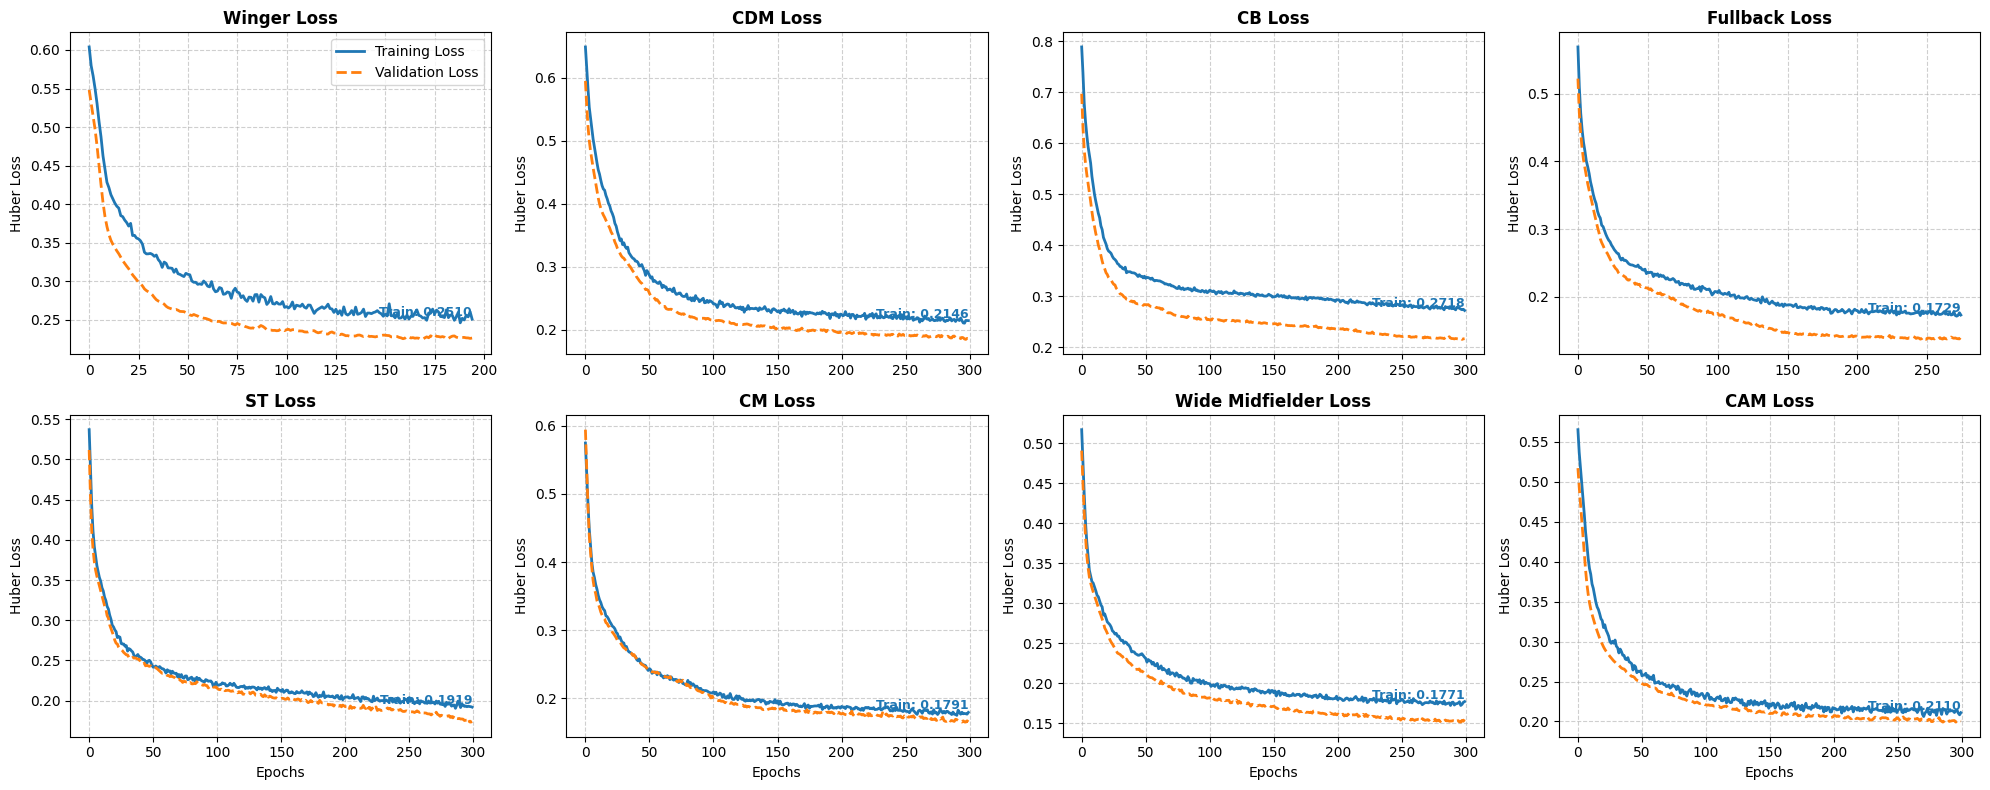


--- All Position-Specific Anomalies (Z-Score > 2.5) ---
Total anomalies found: 321


,player,age,team,pos,macro_pos,league,season,robust_anomaly_score
1756,Joško Gvardiol,20,RB Leipzig,LB,Fullback,GER-Bundesliga,2022 - 2023,17.356824
61,Bruno Méndez,23,Granada,LW,Winger,ESP-La Liga,2023 - 2024,17.269082
1561,Jeremie Frimpong,22,Leverkusen,RB,Fullback,GER-Bundesliga,2023 - 2024,14.830041
118,Lionel Messi,35,Paris S-G,RW,Winger,FRA-Ligue 1,2022 - 2023,14.003829
1364,Lars Ritzka,26,St. Pauli,LB,Fullback,GER-Bundesliga,2024 - 2025,11.967443
2806,Lamine Yamal,17,Barcelona,RM,Wide Midfielder,ESP-La Liga,2024 - 2025,11.487730
1626,Kingsley Ehizibue,28,Udinese,RB,Fullback,ITA-Serie A,2023 - 2024,9.401562
2942,Andre Brooks,19,Sheffield Utd,RM,Wide Midfielder,ENG-Premier League,2023 - 2024,8.937178
2149,Antoine Griezmann,31,Atlético Madrid,ST,ST,ESP-La Liga,2022 - 2023,8.747615
2471,Oliver Arblaster,19,Sheffield Utd,CM,CM,ENG-Premier League,2023 - 2024,8.683630


In [ ]:
%%script echo skipping
models_dict = {}
scalers_dict = {}

# Remove noisy features from the original feature set before training the autoencoder
X_clean = X.drop(columns=noisy_columns, errors='ignore')
features_clean = [col for col in X.columns if col not in noisy_columns]

# Set up a loop to train an autoencoder for each macro-position and extract reconstruction errors
all_reconstruction_errors_by_pos = []
loss_curves_dict = {}
MIN_SAMPLES = 50 

for pos_name in unique_macro_positions:
    position_mask = df_info_reset['macro_pos'] == pos_name
    X_pos_raw = X_clean[position_mask.values] 
    df_info_pos = df_info_reset[position_mask].copy()
    n_samples = X_pos_raw.shape[0]
    print(f"\nProcessing macro-position: {pos_name} ({n_samples} players)...")
    
    # Check if there are enough samples to train an autoencoder
    if n_samples < MIN_SAMPLES:
        print(f"  ⚠️ Warning: Too few samples ({n_samples}). Skipping to prevent extreme overfitting.")
        continue

    # Split training and validation sets for this macro-position
    X_train_raw, X_val_raw = train_test_split(X_pos_raw, test_size=0.15, random_state=42)
    
    # Local scaler for this macro-position to prevent data leakage across positions
    scaler_pos = QuantileTransformer(output_distribution='normal')
    X_train_scaled = scaler_pos.fit_transform(X_train_raw)
    X_val_scaled = scaler_pos.transform(X_val_raw)
    
    input_dim = X_train_scaled.shape[1]
    
    # Dynamic autoencoder architecture based on the number of samples in this macro-position
    input_layer = layers.Input(shape=(input_dim,))
    
    if n_samples >= 250:
        encoded = layers.Dense(32, activation='tanh')(input_layer)
        encoded = layers.Dropout(0.2)(encoded)
        encoded = layers.Dense(16, activation='tanh')(encoded)
        bottleneck = layers.Dense(8, activation='linear', name='dna_bottleneck')(encoded)
        decoded = layers.Dense(16, activation='tanh')(bottleneck)
        decoded = layers.Dense(32, activation='tanh')(decoded)
        decoded = layers.Dropout(0.2)(decoded)
        
    elif n_samples >= 100:
        encoded = layers.Dense(24, activation='tanh')(input_layer)
        encoded = layers.Dropout(0.2)(encoded)
        bottleneck = layers.Dense(6, activation='linear', name='dna_bottleneck')(encoded)
        decoded = layers.Dense(24, activation='tanh')(bottleneck)
        decoded = layers.Dropout(0.2)(decoded)
        
    else:
        encoded = layers.Dense(12, activation='tanh')(input_layer)
        bottleneck = layers.Dense(4, activation='linear', name='dna_bottleneck')(encoded)
        decoded = layers.Dense(12, activation='tanh')(bottleneck)

    output_layer = layers.Dense(input_dim, activation='linear')(decoded)
    
    # Compile and train the autoencoder for this macro-position
    autoencoder_pos = models.Model(inputs=input_layer, outputs=output_layer)
    autoencoder_pos.compile(optimizer='adam', loss='huber') 
    
    early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
    
    history = autoencoder_pos.fit(
        X_train_scaled, X_train_scaled,
        epochs=300,
        batch_size=16 if n_samples < 150 else 32,
        validation_data=(X_val_scaled, X_val_scaled),
        callbacks=[early_stop],
        verbose=0 
    )
    
    # Store the loss curves for this macro-position for later visualization
    loss_curves_dict[pos_name] = history.history
    
    # Compute reconstruction errors on the validation set to derive robust anomaly detection parameters
    # Salva modello e scaler per l'estrazione finale delle feature
    # Salva modello e scaler per l'estrazione finale delle feature
    models_dict[pos_name] = autoencoder_pos
    scalers_dict[pos_name] = scaler_pos
    
    # 1. Calcola gli errori per tutti i giocatori del ruolo con lo scaler locale
    X_all_pos_scaled = scaler_pos.transform(X_pos_raw)
    X_reconstructed_pos = autoencoder_pos.predict(X_all_pos_scaled, verbose=0)
    reconstruction_errors_pos = np.mean((X_all_pos_scaled - X_reconstructed_pos) ** 2, axis=1)
    
    # 2. Calcola i parametri di baseline sull'INTERO set locale (bilancia bias di training e varianza di validation)
    pos_median = np.median(reconstruction_errors_pos)
    pos_mad = np.median(np.abs(reconstruction_errors_pos - pos_median))
    pos_mad = pos_mad if pos_mad > 0 else 1e-6 
    
    anomaly_threshold_95 = np.percentile(reconstruction_errors_pos, 95)
        
    # 3. Applica il punteggio di anomalia robusto
    df_reconstruction_error_pos = df_info_pos.copy()
    df_reconstruction_error_pos['raw_reconstruction_error'] = reconstruction_errors_pos
    df_reconstruction_error_pos['robust_anomaly_score'] = (reconstruction_errors_pos - pos_median) / (pos_mad * 1.4826)
    df_reconstruction_error_pos['is_anomaly'] = reconstruction_errors_pos > anomaly_threshold_95
    
    all_reconstruction_errors_by_pos.append(df_reconstruction_error_pos)
print("\n--- Training Completed for All Macro-Positions ---")

# Plot loss curves for each macro-position to visually inspect training convergence and potential overfitting
if loss_curves_dict:
    print("\nGenerating Loss Convergence Plots...")
    num_plots = len(loss_curves_dict)
    
    cols = min(4, num_plots)
    rows = int(np.ceil(num_plots / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), sharex=False)
    axes = axes.flatten() if num_plots > 1 else [axes]
    
    for i, (pos_name, history) in enumerate(loss_curves_dict.items()):
        ax = axes[i]
        
        train_loss = history['loss']
        val_loss = history['val_loss']
        
        ax.plot(train_loss, color='#1f77b4', linewidth=2, label='Training Loss')
        ax.plot(val_loss, color='#ff7f0e', linewidth=2, linestyle='--', label='Validation Loss')
        
        ax.set_title(f"{pos_name} Loss", fontsize=12, fontweight='bold')
        ax.set_ylabel("Huber Loss")
        ax.grid(True, linestyle='--', alpha=0.6)
        
        if i == 0:
            ax.legend(loc='upper right')
        
        ax.text(len(train_loss)-1, train_loss[-1], f"Train: {train_loss[-1]:.4f}", 
                fontsize=9, va='bottom', ha='right', color='#1f77b4', weight='bold')
        
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    for ax in axes[-cols:]:
        ax.set_xlabel("Epochs")
        
    plt.tight_layout()
    plt.show()

# Compute final table of anomalies across all macro-positions, applying a Z-score threshold to identify statistically significant anomalies

if all_reconstruction_errors_by_pos:
    df_all_position_anomalies = pd.concat(all_reconstruction_errors_by_pos, ignore_index=True)
    
    # Z-score threshold of 2.5 to identify true anomalies
    df_true_anomalies = df_all_position_anomalies[df_all_position_anomalies['robust_anomaly_score'] > 2.5]
    
    print(f"\n--- All Position-Specific Anomalies (Z-Score > 2.5) ---")
    print(f"Total anomalies found: {len(df_true_anomalies)}")
    
    columns_to_show = ['player', 'age', 'team', 'pos', 'macro_pos', 'league', 'season', 'robust_anomaly_score']
    
    display(
        df_true_anomalies
        .sort_values(by='robust_anomaly_score', ascending=False)[columns_to_show]
        .head(15)
    )
else:
    print("\nNo models trained due to insufficient data.")

In [ ]:
%%script echo skipping
# Compute final table of anomalies across all macro-positions, applying a Z-score threshold to identify statistically significant anomalies

if all_reconstruction_errors_by_pos:
    df_all_position_anomalies = pd.concat(all_reconstruction_errors_by_pos, ignore_index=True)
    
    # Z-score threshold of 2.5 to identify true anomalies
    df_true_anomalies = df_all_position_anomalies[df_all_position_anomalies['robust_anomaly_score'] > 2.5]
    
    print(f"\n--- All Position-Specific Anomalies (Z-Score > 2.5) ---")
    print(f"Total anomalies found: {len(df_true_anomalies)}")
    
    columns_to_show = ['player', 'age', 'team', 'pos', 'macro_pos', 'league', 'season', 'robust_anomaly_score']
    
    display(
        df_true_anomalies
        .sort_values(by='robust_anomaly_score', ascending=False)[columns_to_show]
        .head(15)
    )
else:
    print("\nNo models trained due to insufficient data.")


--- All Position-Specific Anomalies (Z-Score > 2.5) ---
Total anomalies found: 321


,player,age,team,pos,macro_pos,league,season,robust_anomaly_score
1756,Joško Gvardiol,20,RB Leipzig,LB,Fullback,GER-Bundesliga,2022 - 2023,17.356824
61,Bruno Méndez,23,Granada,LW,Winger,ESP-La Liga,2023 - 2024,17.269082
1561,Jeremie Frimpong,22,Leverkusen,RB,Fullback,GER-Bundesliga,2023 - 2024,14.830041
118,Lionel Messi,35,Paris S-G,RW,Winger,FRA-Ligue 1,2022 - 2023,14.003829
1364,Lars Ritzka,26,St. Pauli,LB,Fullback,GER-Bundesliga,2024 - 2025,11.967443
2806,Lamine Yamal,17,Barcelona,RM,Wide Midfielder,ESP-La Liga,2024 - 2025,11.487730
1626,Kingsley Ehizibue,28,Udinese,RB,Fullback,ITA-Serie A,2023 - 2024,9.401562
2942,Andre Brooks,19,Sheffield Utd,RM,Wide Midfielder,ENG-Premier League,2023 - 2024,8.937178
2149,Antoine Griezmann,31,Atlético Madrid,ST,ST,ESP-La Liga,2022 - 2023,8.747615
2471,Oliver Arblaster,19,Sheffield Utd,CM,CM,ENG-Premier League,2023 - 2024,8.683630


In [ ]:
%%script echo skipping
# Function to extract the top 3 features that most positively deviate from the macro-position median and the 3 features that most negatively deviate, for a given player index and macro-position
def get_player_feature_deviations(player_scaled, player_reconstructed, features_original):
    # Calcola l'errore direzionale per singola feature (Input Reale - Input Ricostruito)
    # Positivo = il giocatore ha un valore molto più alto di quanto il modello prevedeva per il suo profilo
    # Negativo = il giocatore ha un valore molto più basso del previsto
    errors = (player_scaled - player_reconstructed)[0]
    
    top_3_indices = np.argsort(errors)[-3:][::-1]
    worst_3_indices = np.argsort(errors)[:3] 
    
    top_features = [f"{features_original[i]} (+{errors[i]:.2f})" for i in top_3_indices]
    worst_features = [f"{features_original[i]} ({errors[i]:.2f})" for i in worst_3_indices]
    
    return tuple(top_features + worst_features)

print("Extracting feature deviations for each anomalous player...")

top_1_list = []
top_2_list = []
top_3_list = []
worst_1_list = []
worst_2_list = []
worst_3_list = []

# 1. Crea una copia esplicita per evitare i warning di Pandas
df_final_anomalies = df_true_anomalies.copy()

for idx, row in df_final_anomalies.iterrows(): 
    player_name = row['player']
    macro_position = row['macro_pos'] 
    team_name = row['team'] 
    
    match_mask = (df_info_reset['player'] == player_name) & (df_info_reset['macro_pos'] == macro_position) & (df_info_reset['team'] == team_name)
    if not match_mask.any():
        match_mask = (df_info_reset['player'] == player_name) & (df_info_reset['macro_pos'] == macro_position)
        
    # Usa np.where per trovare la posizione numerica corretta ed evitare KeyError
    row_position = np.where(match_mask)[0][0]
    
    # Estrai i valori RAW originali
    player_raw = X_clean.iloc[row_position].values.reshape(1, -1)
    
    # Recupera scaler e modello specifici per il ruolo
    scaler = scalers_dict[macro_position]
    model = models_dict[macro_position]
    
    # Trasforma e ricostruisci isolando il contesto di ruolo corretto
    player_scaled = scaler.transform(player_raw)
    player_reconstructed = model.predict(player_scaled, verbose=0)
    
    top_1, top_2, top_3, worst_1, worst_2, worst_3 = get_player_feature_deviations(
        player_scaled, player_reconstructed, features_clean
    )
    
    top_1_list.append(top_1)
    top_2_list.append(top_2)
    top_3_list.append(top_3)
    worst_1_list.append(worst_1)
    worst_2_list.append(worst_2)
    worst_3_list.append(worst_3)

# 2. ASSEGNA LE COLONNE AL DATAFRAME CORRETTO (df_final_anomalies, NON df_all_position_anomalies)
df_final_anomalies['Top_Positive_Deviation_1'] = top_1_list
df_final_anomalies['Top_Positive_Deviation_2'] = top_2_list
df_final_anomalies['Top_Positive_Deviation_3'] = top_3_list
df_final_anomalies['Top_Negative_Deviation_1'] = worst_1_list
df_final_anomalies['Top_Negative_Deviation_2'] = worst_2_list
df_final_anomalies['Top_Negative_Deviation_3'] = worst_3_list

print("\nFinal Anomalies Table with Feature Deviations (Sorted by Robust Anomaly Score):")

columns_to_show = [
    'player', 'team', 'pos', 'macro_pos', 'robust_anomaly_score', 
    'Top_Positive_Deviation_1', 'Top_Positive_Deviation_2', 'Top_Positive_Deviation_3', 
    'Top_Negative_Deviation_1', 'Top_Negative_Deviation_2', 'Top_Negative_Deviation_3'
]

# Usa il dataframe corretto per l'ordinamento e la visualizzazione
df_display = df_final_anomalies.sort_values(by='robust_anomaly_score', ascending=False)

display(df_display[columns_to_show].head(15))

Extracting feature deviations for each anomalous player...

Final Anomalies Table with Feature Deviations (Sorted by Robust Anomaly Score):


,player,team,pos,macro_pos,robust_anomaly_score,Top_Positive_Deviation_1,Top_Positive_Deviation_2,Top_Positive_Deviation_3,Top_Negative_Deviation_1,Top_Negative_Deviation_2,Top_Negative_Deviation_3
1756,Joško Gvardiol,RB Leipzig,LB,Fullback,17.356824,Take-Ons_Succ% (+4.89),Touches_Def Pen (+4.09),Touches_Def 3rd (+3.76),Touches_Att 3rd (-5.23),Tackles_Att 3rd (-4.96),Progression_PrgR (-4.59)
61,Bruno Méndez,Granada,LW,Winger,17.269082,Take-Ons_Succ% (+5.56),Standard_G/Sh (+2.41),Touches_Def 3rd (+1.53),Carries_Mis (-4.39),Carries_Dis (-4.24),KP (-3.93)
1561,Jeremie Frimpong,Leverkusen,RB,Fullback,14.830041,Receiving_PrgR (+0.91),Progression_PrgR (+0.91),CrsPA (+0.68),Blocks_Sh (-4.18),Touches_Def 3rd (-1.21),Height (-1.11)
118,Lionel Messi,Paris S-G,RW,Winger,14.003829,Expected_npxG (+3.68),Carries_PrgDist (+3.64),Carries_1/3 (+3.56),Clr (-5.14),Blocks_Sh (-3.70),CrsPA (-1.97)
1364,Lars Ritzka,St. Pauli,LB,Fullback,11.967443,Standard_G/SoT (+4.43),Standard_Dist (+1.95),Standard_Sh/90 (+0.86),Take-Ons_Succ% (-4.52),Standard_SoT (-3.98),Take-Ons_Tkld (-3.33)
2806,Lamine Yamal,Barcelona,RM,Wide Midfielder,11.487730,Standard_Sh/90 (+4.13),Take-Ons_Tkld (+3.44),Standard_Sh (+3.16),Standard_FK (-5.07),Blocks_Sh (-4.25),Blocks_Pass (-1.43)
1626,Kingsley Ehizibue,Udinese,RB,Fullback,9.401562,Height (+1.96),Blocks_Sh (+1.30),Weight (+1.02),1/3 (-1.12),Challenges_Lost (-0.61),Standard_Dist (-0.53)
2942,Andre Brooks,Sheffield Utd,RM,Wide Midfielder,8.937178,Take-Ons_Succ% (+1.45),Carries_Dis (+0.76),Int (+0.73),CrsPA (-4.08),Carries_PrgC (-3.24),Progression_PrgC (-3.24)
2149,Antoine Griezmann,Atlético Madrid,ST,ST,8.747615,Standard_FK (+1.01),Touches_Def 3rd (+0.85),Expected_npxG/Sh (+0.74),Weight (-1.25),Carries_Dis (-0.77),Carries_CPA (-0.75)
2471,Oliver Arblaster,Sheffield Utd,CM,CM,8.683630,Carries_CPA (+1.34),Take-Ons_Succ (+1.01),Blocks_Sh (+0.90),CrsPA (-4.75),Standard_Sh/90 (-3.60),Progression_PrgR (-3.25)


In [304]:
df_display.to_csv("resources/anomalies_per_pos_AE.csv", index=False)

## End

In [305]:
end_time = time.time()

In [306]:

elapsed_time = end_time - start_time
elapsed_minutes = round(elapsed_time / 60)
remaining_seconds = round(elapsed_time % 60)
print(f"\nTotal execution time: {elapsed_minutes:.0f}.{remaining_seconds:.0f} min")


Total execution time: 8.17 min
